In [4]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [5]:
import requests
import pandas as pd

In [6]:
API_KEY = "8cd8826f367b47c69abe4d87fd56115e"

In [7]:
url = (
    f"https://newsapi.org/v2/everything?"
    f"q=NEET%20UG&"
    f"from=2026-06-23&"
    f"to=2026-07-23&"
    f"language=en&"
    f"sortBy=publishedAt&"
    f"apiKey={API_KEY}"
)

In [8]:
response = requests.get(url)
data = response.json()

In [9]:
print(data.keys())

dict_keys(['status', 'totalResults', 'articles'])


In [10]:
print("Status:", data["status"])
print("Total Articles:", data["totalResults"])

Status: ok
Total Articles: 211


In [11]:
data["articles"][0]

{'source': {'id': 'the-times-of-india', 'name': 'The Times of India'},
 'author': 'TOI Education',
 'title': 'CLAT 2027 syllabus, exam pattern unchanged for UG, PG exams; Consortium issues official update',
 'description': 'CLAT 2027 will maintain its current syllabus and examination format for all candidates. The Consortium confirmed no syllabus changes during a recent Governing Body meeting. Expert committee recommendations will be reviewed for potential implementation in CLAT…',
 'url': 'https://timesofindia.indiatimes.com/education/news/clat-2027-syllabus-exam-pattern-unchanged-for-ug-pg-exams-consortium-issues-official-update/articleshow/132557638.cms',
 'urlToImage': 'https://static.toiimg.com/thumb/msid-132558774,width-1280,height-720,resizemode-6,overlay-toi_sw,pt-32,y_pad-600/photo.jpg',
 'publishedAt': '2026-07-22T12:02:01Z',
 'content': '<ul><li>News</li>\r\n<li>Education News</li>\r\n<li>News</li>\r\n<li>CLAT 2027 syllabus, exam pattern unchanged for UG, PG exams; Consortiu

In [12]:
news_list = []

In [13]:
for article in data["articles"]:
    news_list.append({
        "Date": article["publishedAt"],
        "Source": article["source"]["name"],
        "Title": article["title"],
        "Description": article["description"],
        "URL": article["url"]
    })

In [14]:
news_df = pd.DataFrame(news_list)

In [15]:
news_df.head()

,Date,Source,Title,Description,URL
0,2026-07-22T12:02:01Z,The Times of India,"CLAT 2027 syllabus, exam pattern unchanged for...",CLAT 2027 will maintain its current syllabus a...,https://timesofindia.indiatimes.com/education/...
1,2026-07-22T10:15:53Z,The Times of India,"In 1997, Dharmendra Pradhan protested against ...","Dharmendra Pradhan 1997 protest: In 1997, Dhar...",https://economictimes.indiatimes.com/news/new-...
2,2026-07-22T07:54:21Z,The Times of India,Dharmendra Pradhan says NEET UG will go fully ...,NEET UG will fully adopt computer-based testin...,https://economictimes.indiatimes.com/news/new-...
3,2026-07-22T06:32:38Z,The Times of India,"""Who will you listen to, if not students?"": TM...",Trinamool Congress MP Kalyan Banerjee backed s...,https://economictimes.indiatimes.com/news/poli...
4,2026-07-22T04:08:09Z,The Times of India,"Panshul Bansal, NEET-UG topper, explains why h...","Panshul Bansal, a NEET-UG 2026 re-examination ...",https://economictimes.indiatimes.com/news/new-...


In [18]:
news_df.to_csv("news_headlines.csv", index=False)

In [19]:
print("File saved successfully!")

File saved successfully!


In [20]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Source       100 non-null    object
 2   Title        100 non-null    object
 3   Description  100 non-null    object
 4   URL          100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB


In [21]:
news_df.describe(include="all")

,Date,Source,Title,Description,URL
count,100,100,100,100,100
unique,100,6,100,100,100
top,2026-07-22T12:02:01Z,The Times of India,"CLAT 2027 syllabus, exam pattern unchanged for...",CLAT 2027 will maintain its current syllabus a...,https://timesofindia.indiatimes.com/education/...
freq,1,89,1,1,1


In [22]:
news_df.isnull().sum()

Date           0
Source         0
Title          0
Description    0
URL            0
dtype: int64

In [23]:
news_df.shape

(100, 5)

In [24]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Source       100 non-null    object
 2   Title        100 non-null    object
 3   Description  100 non-null    object
 4   URL          100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB


In [25]:
news_df = news_df.dropna(subset=["Title", "Description"])

In [27]:
news_df.duplicated().sum()

0

In [28]:
print("Total Articles:", len(news_df))

Total Articles: 100


In [29]:
news_df["Source"].value_counts()

Source
The Times of India    89
BusinessLine           6
Khabarhub.com          2
Economictimes.com      1
Biztoc.com             1
Southasiaviews.com     1
Name: count, dtype: int64

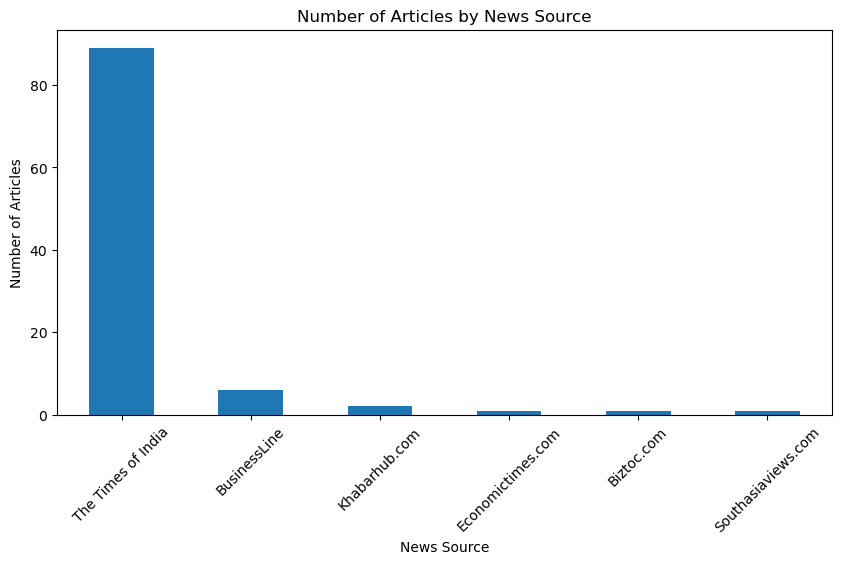

In [32]:
import matplotlib.pyplot as plt
news_df["Source"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Number of Articles by News Source")
plt.xlabel("News Source")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

In [33]:
news_df["Date"] = pd.to_datetime(news_df["Date"])

In [34]:
news_df["Only_Date"] = news_df["Date"].dt.date

In [35]:
daily_articles = news_df.groupby("Only_Date").size()
daily_articles

Only_Date
2026-07-17    35
2026-07-18    13
2026-07-19    12
2026-07-20    25
2026-07-21     8
2026-07-22     7
dtype: int64

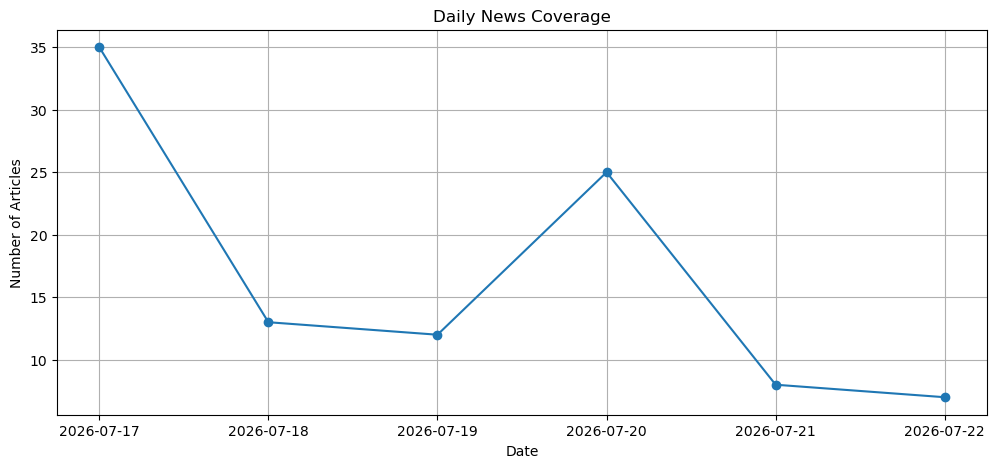

In [36]:
plt.figure(figsize=(12,5))
daily_articles.plot(marker="o")
plt.title("Daily News Coverage")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.grid(True)
plt.show()

In [37]:
pip install vaderSentiment

   ---------------------------------------- 0.0/126.0 kB ? eta -:--:--
   --- ------------------------------------ 10.2/126.0 kB ? eta -:--:--
   --- ------------------------------------ 10.2/126.0 kB ? eta -:--:--
   --- ------------------------------------ 10.2/126.0 kB ? eta -:--:--
   --------- ----------------------------- 30.7/126.0 kB 186.2 kB/s eta 0:00:01
   --------- ----------------------------- 30.7/126.0 kB 186.2 kB/s eta 0:00:01
   ------------------- ------------------- 61.4/126.0 kB 217.9 kB/s eta 0:00:01
   --------------------------------- ---- 112.6/126.0 kB 363.1 kB/s eta 0:00:01
   -------------------------------------- 126.0/126.0 kB 352.8 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [38]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [39]:
analyzer = SentimentIntensityAnalyzer()

In [40]:
text = "Students welcomed the government's decision."
score = analyzer.polarity_scores(text)
print(score)

{'neg': 0.0, 'neu': 0.625, 'pos': 0.375, 'compound': 0.34}


In [41]:
def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))
    
    if score["compound"] >= 0.05:
        return "Positive"
    elif score["compound"] <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [42]:
news_df["Sentiment"] = news_df["Title"].apply(get_sentiment)

In [43]:
news_df[["Title", "Sentiment"]].head(10)

,Title,Sentiment
0,"CLAT 2027 syllabus, exam pattern unchanged for...",Neutral
1,"In 1997, Dharmendra Pradhan protested against ...",Negative
2,Dharmendra Pradhan says NEET UG will go fully ...,Positive
3,"""Who will you listen to, if not students?"": TM...",Negative
4,"Panshul Bansal, NEET-UG topper, explains why h...",Negative
5,Opposition using protest to find political rel...,Negative
6,"Jaishankar flags supply chain risks, calls for...",Negative
7,Peddapalli MP demands Pradhan’s resignation ov...,Negative
8,MP High Court grants centre time to reply in N...,Positive
9,Why Was Rahul Gandhi Detained During The Stude...,Negative


In [44]:
news_df["Sentiment"].value_counts()


Sentiment
Negative    39
Neutral     34
Positive    27
Name: count, dtype: int64

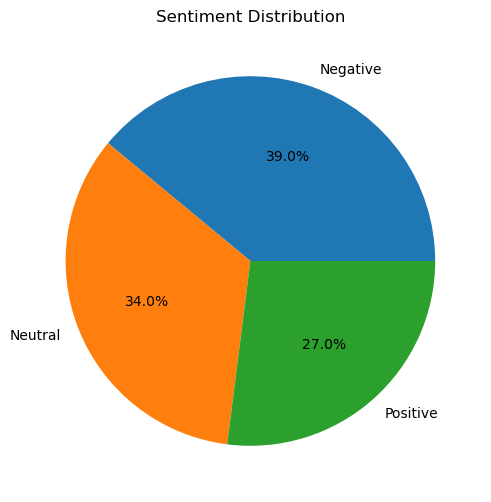

In [45]:
import matplotlib.pyplot as plt

news_df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

In [46]:
daily_news = news_df.groupby("Only_Date").size().reset_index(name="News_Count")
daily_news.head()

,Only_Date,News_Count
0,2026-07-17,35
1,2026-07-18,13
2,2026-07-19,12
3,2026-07-20,25
4,2026-07-21,8


In [56]:
trend_data = pd.read_csv("google_trends.csv")

In [58]:
trend_data.head()

,Time,NEET UG
0,2026-06-24,10
1,2026-06-25,9
2,2026-06-26,10
3,2026-06-27,11
4,2026-06-28,10


In [62]:
##trend_data = trend_data.reset_index()

In [63]:
##trend_data.head()

In [64]:
print(trend_data.columns)

Index(['index', 'Time', 'NEET UG'], dtype='object')


In [66]:
trend_data["Time"] = pd.to_datetime(trend_data["Time"]).dt.date

In [67]:
trend_data.head()

,index,Time,NEET UG
0,0,2026-06-24,10
1,1,2026-06-25,9
2,2,2026-06-26,10
3,3,2026-06-27,11
4,4,2026-06-28,10


In [68]:
merged_df = pd.merge(
    trend_data,
    daily_news,
    left_on="Time",
    right_on="Only_Date",
    how="inner"
)

In [69]:
merged_df.head()

,index,Time,NEET UG,Only_Date,News_Count
0,23,2026-07-17,100,2026-07-17,35
1,24,2026-07-18,33,2026-07-18,13
2,25,2026-07-19,21,2026-07-19,12
3,26,2026-07-20,19,2026-07-20,25
4,27,2026-07-21,18,2026-07-21,8


In [70]:
merged_df[["NEET UG", "News_Count"]].corr()

,NEET UG,News_Count
NEET UG,1.00000,0.78276
News_Count,0.78276,1.00000


In [71]:
from scipy.stats import pearsonr

r, p = pearsonr(merged_df["NEET UG"], merged_df["News_Count"])

print("Correlation coefficient (r):", round(r, 4))
print("P-value:", p)

Correlation coefficient (r): 0.7828
P-value: 0.06566395379728007


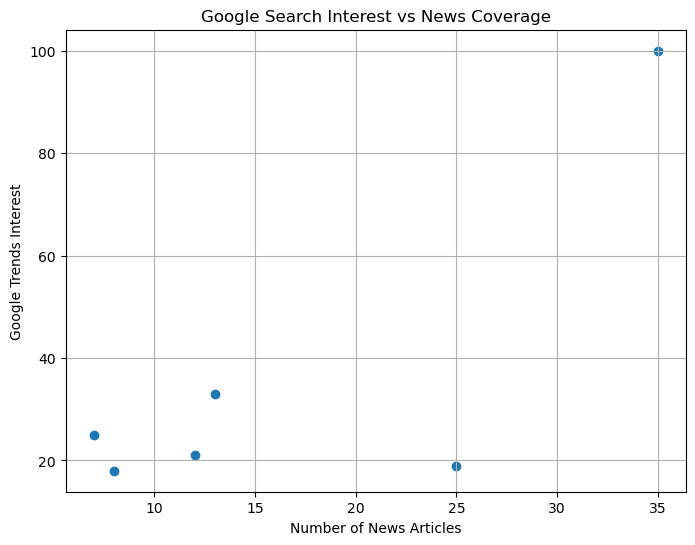

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(merged_df["News_Count"], merged_df["NEET UG"])

plt.title("Google Search Interest vs News Coverage")
plt.xlabel("Number of News Articles")
plt.ylabel("Google Trends Interest")

plt.grid(True)

plt.show()

In [73]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 100))

merged_df["News_Count_Normalized"] = scaler.fit_transform(
    merged_df[["News_Count"]]
)


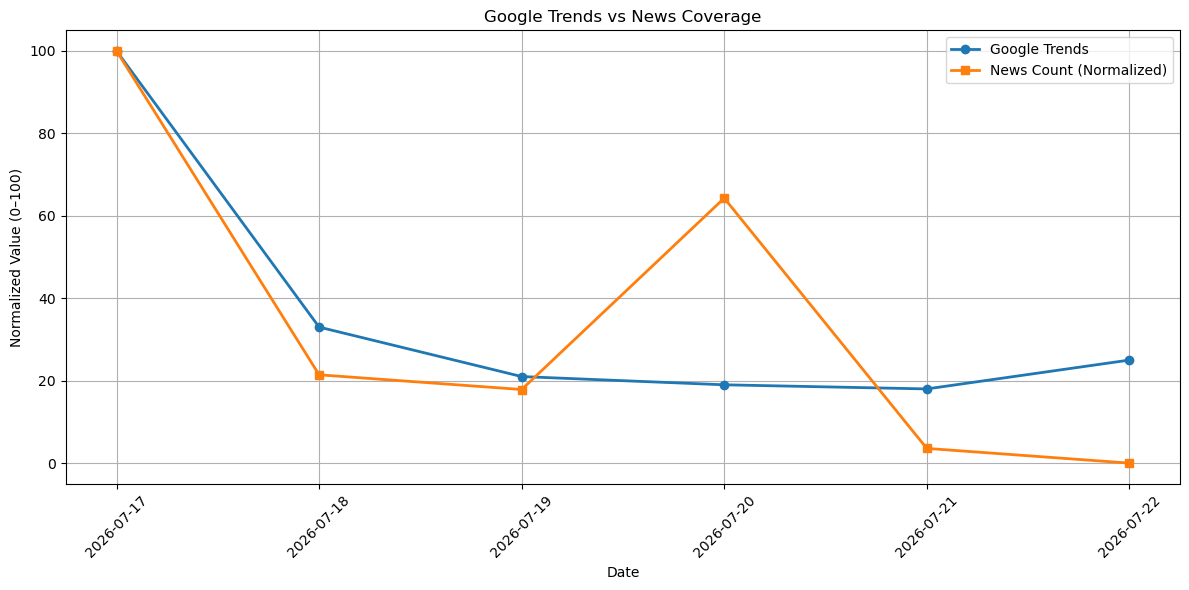

In [74]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(
    merged_df["Time"],
    merged_df["NEET UG"],
    marker="o",
    linewidth=2,
    label="Google Trends"
)
plt.plot(
    merged_df["Time"],
    merged_df["News_Count_Normalized"],
    marker="s",
    linewidth=2,
    label="News Count (Normalized)"
)
plt.title("Google Trends vs News Coverage")
plt.xlabel("Date")
plt.ylabel("Normalized Value (0–100)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

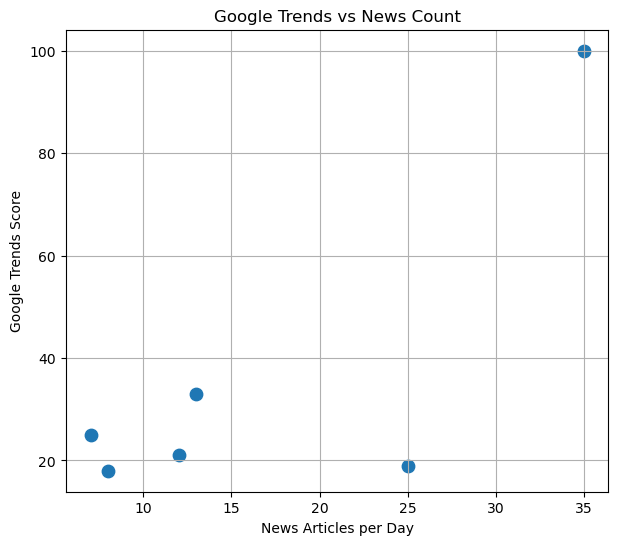

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(
    merged_df["News_Count"],
    merged_df["NEET UG"],
    s=80
)

plt.xlabel("News Articles per Day")
plt.ylabel("Google Trends Score")
plt.title("Google Trends vs News Count")

plt.grid(True)
plt.show()